In [1]:
import pandas as pd 

# Exemplo de dataset simulado

# data = pd.DataFrame({
#     "tempo": [5, 6, 6, 2, 4, 3, 8, 10],
#     "evento": [1, 0, 1, 1, 0, 1, 0, 1],  # 1 = evento aconteceu, 0 = censurado
#     "idade": [50, 60, 45, 70, 55, 65, 80, 40],
#     "pressao": [120, 130, 110, 140, 135, 150, 160, 125],
# }).sort_values("tempo")

link_csv = r'D:\cox-models-sudden-death\01_Dataset\dados_csv_info_definitions\subject-info_formatado.csv'



df = pd.read_csv(link_csv, delimiter=';')

In [2]:
df

,Patient ID,Follow-up period from enrollment (days),days_4years,Exit of the study,Cause of death,SCD_4years SinusRhythm,HF_4years SinusRhythm,Age,Gender (male=1),Weight (kg),...,Angiotensin-II receptor blocker (yes=1),Anticoagulants/antitrombotics (yes=1),Betablockers (yes=1),Digoxin (yes=1),Loop diuretics (yes=1),Spironolactone (yes=1),Statins (yes=1),Hidralazina (yes=1),ACE inhibitor (yes=1),Nitrovasodilator (yes=1)
0,P0001,2065,1460,NaN,0,0,0,58,1,83,...,0,1,1,1,1,0,0,0,1,0
1,P0002,2045,1460,NaN,0,0,0,58,1,74,...,1,1,1,0,0,0,1,0,0,0
2,P0003,2044,1460,NaN,0,0,0,69,1,83,...,1,1,1,1,1,0,0,0,0,0
3,P0004,2044,1460,NaN,0,0,0,56,0,84,...,1,1,1,0,1,1,0,0,0,0
4,P0005,2043,1460,NaN,0,0,0,70,1,97,...,0,1,1,0,1,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
987,P1064,1393,1393,NaN,0,0,0,63,0,67,...,1,1,1,0,1,0,0,0,0,0
988,P1065,1393,1393,NaN,0,0,0,80,1,79,...,0,1,0,1,1,0,0,0,1,0
989,P1066,1387,1387,NaN,0,0,0,72,0,81,...,0,0,0,0,1,0,0,0,1,0
990,P1073,1365,1365,NaN,0,0,0,70,0,63,...,0,1,1,0,1,0,0,0,1,0


In [3]:
print(f'class 0: {df.query('`Cause of death` == 0').shape[0]}')
print(f'class 1: {df.query('`Cause of death` == 1').shape[0]}')
print(f'class 3: {df.query('`Cause of death` == 3').shape[0]}')
print(f'class 6: {df.query('`Cause of death` == 6').shape[0]}')
print(f'class 7: {df.query('`Cause of death` == 7').shape[0]}')

class 0: 726
class 1: 61
class 3: 94
class 6: 100
class 7: 11


Causa da morte E Causa da morte
- 0: sobrevivente;
- 1: morte não cardíaca;
- 3: SCD;
- 6-7: Morte por falha da bomba;
- Conforme data de encerramento do estudo
- A SCD é causada por arritmias no coração

A arritmia mais comum associada à Morte Súbita Cardíaca é a fibrilação ventricular. Essas arritmias cardíacas são impulsos de disparo rápido das câmaras inferiores do coração (ventrículos).

In [4]:
# qrs_duration = dados['QRS duration (ms)']               # Duração do complexo QRS
# qt_interval = dados['QT interval (ms)']                 # Intervalo QT
# hrv = dados['SDNN (ms)']                                # Variabilidade da frequência cardíaca

idade = df['Age']                                      # Idade dos pacientes
genero = df['Gender (male=1)']                          # 0 = mulher, 1 = homem


tempo = df['Follow-up period from enrollment (days)'] # Tempo até o evento ou censura (dias)
evento = df['Cause of death']                         # 1 = morte cardíaca, 0 = censurado


In [5]:
dados = pd.DataFrame({
    "tempo": tempo.values,
    "evento": evento.values,
    "idade": idade.values,
    "genero": genero.values}).sort_values("tempo")


dados

,tempo,evento,idade,genero
717,33,3,57,1
479,37,3,80,0
648,43,3,69,1
762,46,1,66,0
431,48,7,71,1
...,...,...,...,...
4,2043,0,70,1
3,2044,0,56,0
2,2044,0,69,1
1,2045,0,58,1


In [6]:
dados.head()

,tempo,evento,idade,genero
717,33,3,57,1
479,37,3,80,0
648,43,3,69,1
762,46,1,66,0
431,48,7,71,1


In [7]:
# 0 sobreviventes, censurados 1 (6 arritmia)
dados = dados.query('(evento == 0) or (evento == 6)')

# lipando os indices e ordenando
dados = dados.reset_index(drop=True).sort_values("tempo")

# passando evento tipo 6 para 1 (considerando como evento)
dados['evento'] = dados['evento'].replace(6, 1)

In [8]:
dados.head(10)

,tempo,evento,idade,genero
0,110,1,74,1
1,116,0,56,1
2,118,1,64,1
3,122,0,52,1
4,125,0,72,1
5,133,1,73,1
6,133,1,63,1
7,138,1,73,0
8,148,1,62,0
9,153,0,82,1


In [9]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 826 entries, 0 to 825
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   tempo   826 non-null    int64
 1   evento  826 non-null    int64
 2   idade   826 non-null    int64
 3   genero  826 non-null    int64
dtypes: int64(4)
memory usage: 32.3 KB


## Kaplan–Meier: Documentação e Fórmulas

### Introdução

O método de Kaplan-Meier é utilizado para estimar a função de sobrevivência a partir de dados de tempo até evento, considerando censura. Abaixo, documentamos cada etapa do cálculo, apresentando as fórmulas matemáticas utilizadas.

---

### 1. Número em risco (`n_i`)

Para cada tempo \( t_i \), o número de indivíduos ainda em risco é:

\[
n_i = \text{número de indivíduos com tempo} \geq t_i
\]

---

### 2. Número de eventos (`d_i`)

Para cada tempo \( t_i \):

\[
d_i = \text{número de eventos observados em } t_i
\]

---

### 3. Probabilidade de sobreviver no tempo (`v_i`)

A probabilidade de sobreviver imediatamente após o tempo \( t_i \):

\[
v_i = 1 - \frac{d_i}{n_i}
\]

---

### 4. Função de Sobrevivência Acumulada (`S(t)`)

A função de sobrevivência acumulada até o tempo \( t_j \):

\[
S(t_j) = \prod_{i=1}^{j} v_i
\]

---

### 5. Função de Falha (`F(t)`)

A função de falha é o complemento da sobrevivência:

\[
F(t) = 1 - S(t)
\]

---

### 6. Erro Padrão (Greenwood)

O erro padrão de \( S(t) \) é calculado pela fórmula de Greenwood:

\[
SE[S(t)] = S(t) \cdot \sqrt{ \sum_{i=1}^{j} \frac{d_i}{n_i (n_i - d_i)} }
\]

---

### 7. Intervalo de Confiança 95%

O intervalo de confiança para \( S(t) \) é dado por:

\[
IC_{95\%} = \left[ \max(0, S(t) - 1.96 \cdot SE),\ \min(1, S(t) + 1.96 \cdot SE) \right]
\]

---

### 8. Resumo das Variáveis

- `n_risco`: número de indivíduos em risco no tempo \( t \)
- `d_evento`: número de eventos no tempo \( t \)
- `v_i`: probabilidade de sobreviver no tempo \( t \)
- `S_t`: sobrevivência acumulada até o tempo \( t \)
- `F_t`: probabilidade acumulada de falha até o tempo \( t \)
- `SE`: erro padrão de \( S_t \)
- `CI_lower`, `CI_upper`: limites inferior e superior do intervalo de confiança de 95%

---

### 9. Exemplo de Cálculo

Para cada tempo com evento, os valores são calculados conforme as fórmulas acima e armazenados nas listas correspondentes.

---

### Referências

- Kaplan, E. L., & Meier, P. (1958). Nonparametric estimation from incomplete observations. Journal of the American Statistical Association, 53(282), 457–481.
- Collett, D. (2015). Modelling Survival Data in Medical Research.

---

In [10]:
# para a formula funcionar o evento tem que estar ordenado por tempo crescente como,  .sort_values("tempo")

# Listas para armazenar os resultados
n_risco_list = []   # n_i
v_list = []         # v_i
S_list = []         # R(t) = S(t)
F_list = []         # F(t)

print("\nCálculo Kaplan–Meier passo a passo:")

S_t = 1  # S(0) = 1

for i, t in enumerate(dados["tempo"]):
    n_risco = dados["tempo"].iloc[i:].count()      # n_i
    d_evento = dados["evento"].iloc[i]             # d_i (aqui linha a linha)
    
    v_i = (n_risco - d_evento) / n_risco          # v_i = 1 - d_i/n_i
    S_t = S_t * v_i                               # S(t) acumulado
    F_t = 1 - S_t                                 # F(t) = 1 - S(t)
    
    # Armazenar
    n_risco_list.append(n_risco)
    v_list.append(v_i)
    S_list.append(S_t)
    F_list.append(F_t)
    
    # Mostrar passo a passo
    print(f"Tempo={t:3} | n={n_risco:2} | d={d_evento} | v={v_i:.3f} | S(t)={S_t:.3f} | F(t)={F_t:.3f}")
    
# Adicionar os resultados ao DataFrame
resultado = pd.DataFrame({
    "tempo": dados["tempo"],
    "evento": dados["evento"],
    "n_risco": n_risco_list,
    "v": v_list,
    "S(t)": S_list,
    "F(t)": F_list
})



Cálculo Kaplan–Meier passo a passo:
Tempo=110 | n=826 | d=1 | v=0.999 | S(t)=0.999 | F(t)=0.001
Tempo=116 | n=825 | d=0 | v=1.000 | S(t)=0.999 | F(t)=0.001
Tempo=118 | n=824 | d=1 | v=0.999 | S(t)=0.998 | F(t)=0.002
Tempo=122 | n=823 | d=0 | v=1.000 | S(t)=0.998 | F(t)=0.002
Tempo=125 | n=822 | d=0 | v=1.000 | S(t)=0.998 | F(t)=0.002
Tempo=133 | n=821 | d=1 | v=0.999 | S(t)=0.996 | F(t)=0.004
Tempo=133 | n=820 | d=1 | v=0.999 | S(t)=0.995 | F(t)=0.005
Tempo=138 | n=819 | d=1 | v=0.999 | S(t)=0.994 | F(t)=0.006
Tempo=148 | n=818 | d=1 | v=0.999 | S(t)=0.993 | F(t)=0.007
Tempo=153 | n=817 | d=0 | v=1.000 | S(t)=0.993 | F(t)=0.007
Tempo=166 | n=816 | d=1 | v=0.999 | S(t)=0.992 | F(t)=0.008
Tempo=166 | n=815 | d=1 | v=0.999 | S(t)=0.990 | F(t)=0.010
Tempo=173 | n=814 | d=1 | v=0.999 | S(t)=0.989 | F(t)=0.011
Tempo=173 | n=813 | d=0 | v=1.000 | S(t)=0.989 | F(t)=0.011
Tempo=177 | n=812 | d=0 | v=1.000 | S(t)=0.989 | F(t)=0.011
Tempo=179 | n=811 | d=0 | v=1.000 | S(t)=0.989 | F(t)=0.011
Tem

In [11]:
resultado["S(t)"].min()

np.float64(0.8750301423383521)

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_kaplan_meier(resultado):
        # Configurar um estilo visual mais agradável
        sns.set_style("whitegrid")

        plt.figure(figsize=(10, 6))

        # O segredo para o gráfico de "escada" é o drawstyle='steps-post'
        plt.step(resultado["tempo"], resultado["S(t)"], where='post')

        # Melhorando o gráfico
        plt.title('Curva de Sobrevivência de Kaplan-Meier', fontsize=16)
        plt.xlabel('Tempo', fontsize=12)
        plt.ylabel('Probabilidade de Sobrevivência (S(t))', fontsize=12)
        #plt.ylim(0, 1.05) # Limites do eixo y de 0 a 100%
        plt.ylim(resultado["S(t)"].min(), resultado["S(t)"].max() ) # Limites do eixo y de 0 a 100%
        plt.xlim(left=0) # Eixo x começa no tempo 0
        plt.grid(True)

        plt.show()


        plt.figure(figsize=(10, 6))

        plt.step(resultado["tempo"], resultado["F(t)"], where='post', color='red')

        plt.title('Função de Incidência Cumulativa', fontsize=16)
        plt.xlabel('Tempo', fontsize=12)
        plt.ylabel('Probabilidade de Falha (F(t))', fontsize=12)
        plt.ylim(0, 1.05)
        plt.xlim(left=0)
        plt.grid(True)

        plt.show()


        import numpy as np

        # Calcular a função de risco cumulativo
        # Adicionamos um valor muito pequeno a S(t) para evitar log(0)
        risco_cumulativo = -np.log(resultado["S(t)"] + 1e-9)

        plt.figure(figsize=(10, 6))

        plt.step(resultado["tempo"], risco_cumulativo, where='post', color='green')

        plt.title('Função de Risco Cumulativo', fontsize=16)
        plt.xlabel('Tempo', fontsize=12)
        plt.ylabel('Risco Cumulativo (H(t))', fontsize=12)
        plt.xlim(left=0)
        plt.grid(True)

        plt.show()


        # pip install lifelines

        from lifelines import KaplanMeierFitter

        # Supondo que 'dados' é o seu DataFrame original com 'tempo' e 'evento'
        T = dados['tempo']
        E = dados['evento']

        # Criar e ajustar o modelo
        kmf = KaplanMeierFitter()
        kmf.fit(T, E, label='Estimativa de Sobrevivência')

        # Plotar o gráfico
        plt.figure(figsize=(10, 6))
        kmf.plot_survival_function()
        plt.title('Curva de Sobrevivência de Kaplan-Meier com Intervalo de Confiança')
        plt.grid(True)
        plt.show()

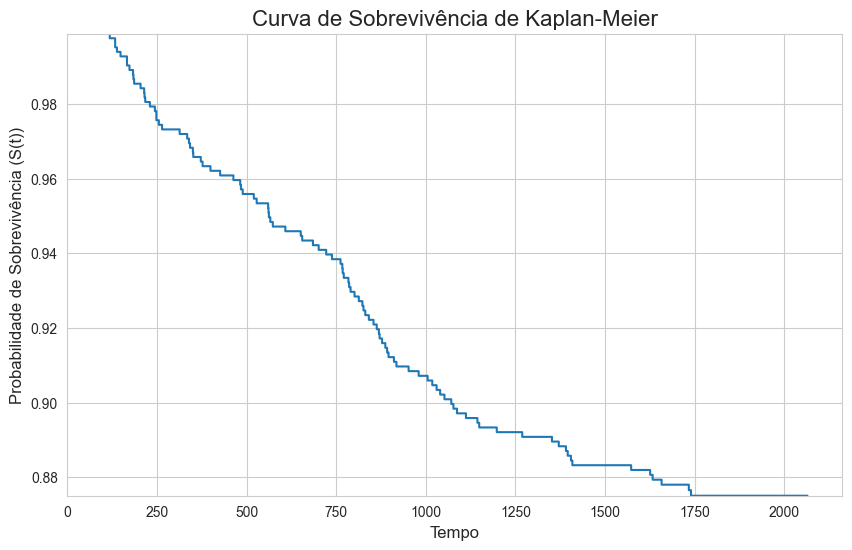

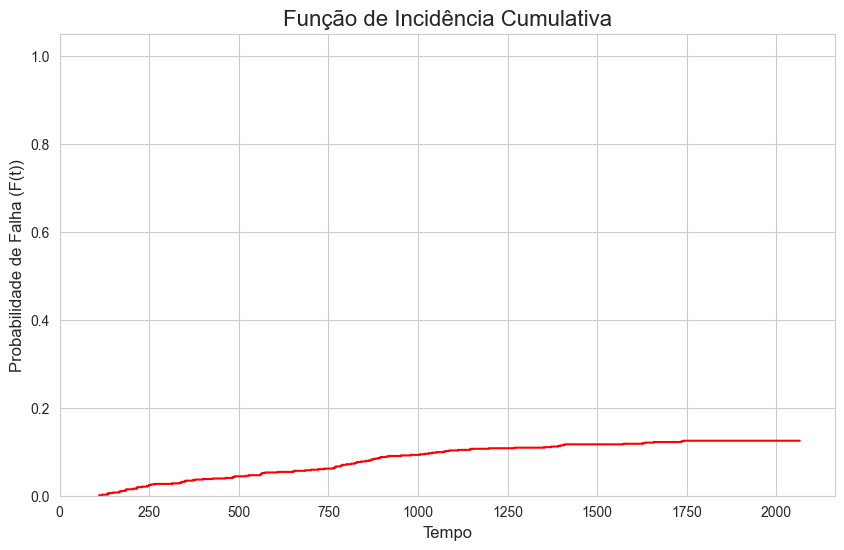

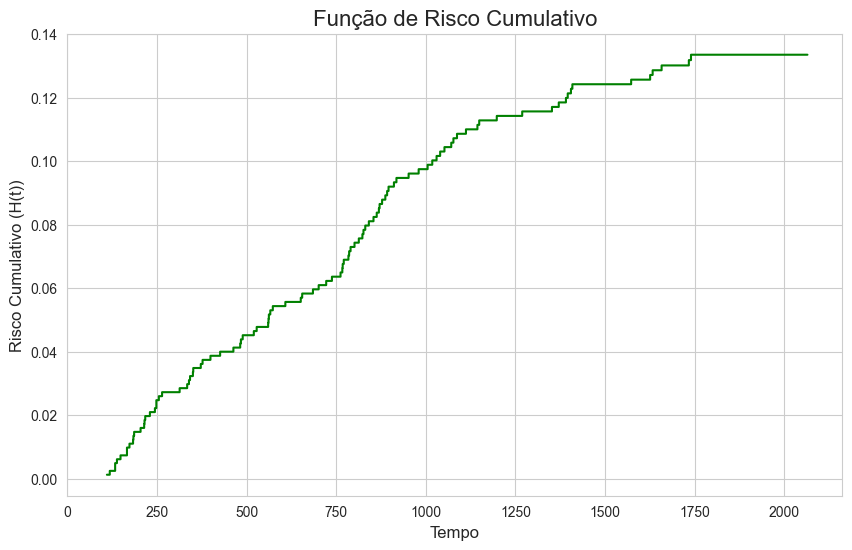

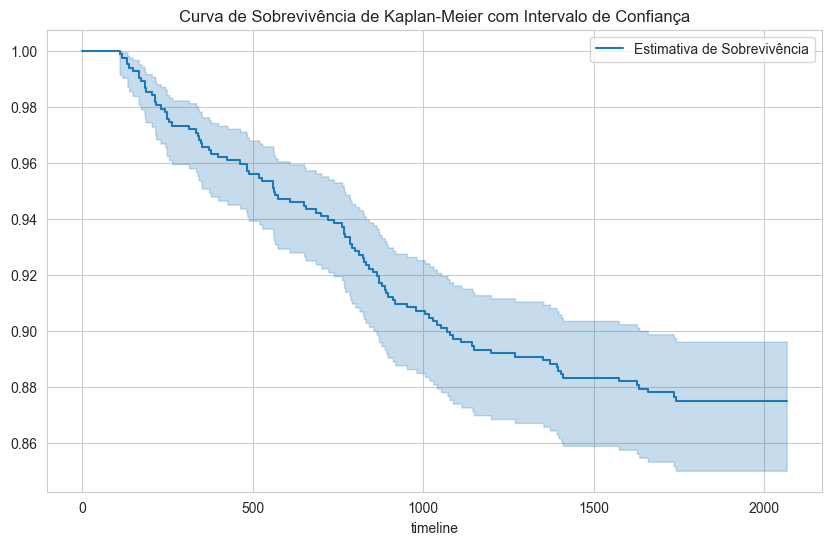

In [13]:
plot_kaplan_meier(resultado)

In [14]:
resultado.round(2)


,tempo,evento,n_risco,v,S(t),F(t)
0,110,1,826,1.0,1.00,0.00
1,116,0,825,1.0,1.00,0.00
2,118,1,824,1.0,1.00,0.00
3,122,0,823,1.0,1.00,0.00
4,125,0,822,1.0,1.00,0.00
...,...,...,...,...,...,...
821,2043,0,5,1.0,0.88,0.12
822,2044,0,4,1.0,0.88,0.12
823,2044,0,3,1.0,0.88,0.12
824,2045,0,2,1.0,0.88,0.12


In [15]:
import pandas as pd
import numpy as np


# --- Agrupar por tempo ---
# Para cada tempo, contar número em risco (n_i) e número de eventos (d_i)
resumo = dados.groupby("tempo").agg(
    #n_risco=('evento', 'count'),
    eventos=('evento', 'sum')
).reset_index()

# --- Inicializações ---
S_t = 1  # Probabilidade de sobrevivência inicial S(0)
lista_S = []          # Para armazenar S(t)
lista_F = []          # Para armazenar F(t) = 1 - S(t)
lista_SE = []         # Erro padrão
lista_CI_lower = []   # Limite inferior 95% CI
lista_CI_upper = []   # Limite superior 95% CI

soma_greenwood = 0    # Variável para soma de Greenwood

# --- Cálculo passo a passo ---
print("\nCálculo Kaplan–Meier passo a passo:\n")
for i, linha in resumo.iterrows():
    
    tempo = linha['tempo']
    n_risco = dados["tempo"].iloc[i:].count()      # n_i
    d_evento = linha['eventos']       # d_i
    
    # Probabilidade de sobreviver neste tempo
    v_i = (n_risco - d_evento) / n_risco          # v_i = 1 - d_i/n_i
    S_t = S_t * v_i                               # S(t) acumulado
    F_t = 1 - S_t                                 # F(t) = 1 - S(t)
    
    # --- Erro padrão via fórmula de Greenwood ---
    if n_risco - d_evento > 0:
        soma_greenwood += d_evento / (n_risco * (n_risco - d_evento))
    SE = S_t * np.sqrt(soma_greenwood)
    
    # --- Intervalo de confiança 95% ---
    CI_lower = max(0, S_t - 1.96 * SE)
    CI_upper = min(1, S_t + 1.96 * SE)
    
    # Armazenar resultados
    lista_S.append(S_t) # S(t)
    lista_F.append(F_t) # F(t)
    lista_SE.append(SE) # Erro padrão
    lista_CI_lower.append(CI_lower) # Limite inferior CI
    lista_CI_upper.append(CI_upper) # Limite superior CI
    
    # Mostrar passo a passo
    print(f"Tempo={tempo:3} | n={n_risco:2} | d={d_evento:2} | v={v_i:.3f} | S(t)={S_t:.3f} | F(t)={F_t:.3f} | SE={SE:.3f} | 95% CI=({CI_lower:.3f}, {CI_upper:.3f})")

# --- 5. Criar DataFrame final ---
resumo['S(t)'] = lista_S
resumo['F(t)'] = lista_F
resumo['Erro Padrão'] = lista_SE
resumo['95% CI Lower'] = lista_CI_lower
resumo['95% CI Upper'] = lista_CI_upper




Cálculo Kaplan–Meier passo a passo:

Tempo=110 | n=826 | d= 1 | v=0.999 | S(t)=0.999 | F(t)=0.001 | SE=0.001 | 95% CI=(0.996, 1.000)
Tempo=116 | n=825 | d= 0 | v=1.000 | S(t)=0.999 | F(t)=0.001 | SE=0.001 | 95% CI=(0.996, 1.000)
Tempo=118 | n=824 | d= 1 | v=0.999 | S(t)=0.998 | F(t)=0.002 | SE=0.002 | 95% CI=(0.994, 1.000)
Tempo=122 | n=823 | d= 0 | v=1.000 | S(t)=0.998 | F(t)=0.002 | SE=0.002 | 95% CI=(0.994, 1.000)
Tempo=125 | n=822 | d= 0 | v=1.000 | S(t)=0.998 | F(t)=0.002 | SE=0.002 | 95% CI=(0.994, 1.000)
Tempo=133 | n=821 | d= 2 | v=0.998 | S(t)=0.995 | F(t)=0.005 | SE=0.002 | 95% CI=(0.990, 1.000)
Tempo=138 | n=820 | d= 1 | v=0.999 | S(t)=0.994 | F(t)=0.006 | SE=0.003 | 95% CI=(0.989, 0.999)
Tempo=148 | n=819 | d= 1 | v=0.999 | S(t)=0.993 | F(t)=0.007 | SE=0.003 | 95% CI=(0.987, 0.999)
Tempo=153 | n=818 | d= 0 | v=1.000 | S(t)=0.993 | F(t)=0.007 | SE=0.003 | 95% CI=(0.987, 0.999)
Tempo=166 | n=817 | d= 2 | v=0.998 | S(t)=0.990 | F(t)=0.010 | SE=0.003 | 95% CI=(0.984, 0.997)
Te

In [16]:
import pandas as pd
import numpy as np

print(f"\nTotal de observações: {len(dados)}")

# ---  Agrupar por tempo ---
# Para cada tempo, contar número de eventos
resumo = dados.groupby("tempo").agg(
    eventos=('evento', 'sum')
).reset_index()

print("\nTEMPOS E EVENTOS:")
print(resumo)

# ---  Inicializações ---
S_t = 1  # Probabilidade de sobrevivência inicial S(0)
lista_S = []          # Para armazenar S(t)
lista_F = []          # Para armazenar F(t) = 1 - S(t)
lista_SE = []         # Erro padrão
lista_CI_lower = []   # Limite inferior 95% CI
lista_CI_upper = []   # Limite superior 95% CI

soma_greenwood = 0    # Variável para soma de Greenwood

# ---  Cálculo passo a passo ---
print("\nCálculo Kaplan–Meier passo a passo:\n")
print(f"{'Tempo':>5} | {'n_risco':>7} | {'eventos':>7} | {'v_i':>6} | {'S(t)':>6} | {'F(t)':>6} | {'SE':>6} | {'95% CI':>15}")
print("-" * 70)

for i, linha in resumo.iterrows():    
    tempo = linha['tempo']
    d_evento = linha['eventos']       # d_i
    
    # CORREÇÃO: n_risco = quantos ainda estão "em risco" no tempo atual
    # (todos que têm tempo >= tempo atual)
    n_risco = (dados["tempo"] >= tempo).sum()
    
    # Só calcular se houve eventos (d_evento > 0)
    if d_evento > 0:
        # Probabilidade de sobreviver neste tempo
        v_i = (n_risco - d_evento) / n_risco          # v_i = 1 - d_i/n_i
        S_t = S_t * v_i                               # S(t) acumulado
        F_t = 1 - S_t                                 # F(t) = 1 - S(t)
        
        # --- Erro padrão via fórmula de Greenwood ---
        if n_risco - d_evento > 0:
            soma_greenwood += d_evento / (n_risco * (n_risco - d_evento))
        SE = S_t * np.sqrt(soma_greenwood)
        
        # --- Intervalo de confiança 95% ---
        CI_lower = max(0, S_t - 1.96 * SE)
        CI_upper = min(1, S_t + 1.96 * SE)
        
        # Armazenar resultados
        lista_S.append(S_t) # S(t)
        lista_F.append(F_t) # F(t)
        lista_SE.append(SE) # Erro padrão
        lista_CI_lower.append(CI_lower) # Limite inferior CI
        lista_CI_upper.append(CI_upper) # Limite superior CI
        
        # Mostrar passo a passo
        print(f"{tempo:5} | {n_risco:7} | {d_evento:7} | {v_i:6.3f} | {S_t:6.3f} | {F_t:6.3f} | {SE:6.3f} | ({CI_lower:5.3f}, {CI_upper:5.3f})")

# ---  Criar DataFrame final apenas com tempos onde houve eventos ---
tempos_eventos = dados[dados['evento'] == 1].groupby('tempo').size().reset_index()['tempo']
resumo_final = pd.DataFrame({
    'tempo': tempos_eventos,
    'S(t)': lista_S,
    'F(t)': lista_F,
    'Erro Padrão': lista_SE,
    '95% CI Lower': lista_CI_lower,
    '95% CI Upper': lista_CI_upper
})


Total de observações: 826

TEMPOS E EVENTOS:
     tempo  eventos
0      110        1
1      116        0
2      118        1
3      122        0
4      125        0
..     ...      ...
371   2042        0
372   2043        0
373   2044        0
374   2045        0
375   2065        0

[376 rows x 2 columns]

Cálculo Kaplan–Meier passo a passo:

Tempo | n_risco | eventos |    v_i |   S(t) |   F(t) |     SE |          95% CI
----------------------------------------------------------------------
  110 |     826 |       1 |  0.999 |  0.999 |  0.001 |  0.001 | (0.996, 1.000)
  118 |     824 |       1 |  0.999 |  0.998 |  0.002 |  0.002 | (0.994, 1.000)
  133 |     821 |       2 |  0.998 |  0.995 |  0.005 |  0.002 | (0.990, 1.000)
  138 |     819 |       1 |  0.999 |  0.994 |  0.006 |  0.003 | (0.989, 0.999)
  148 |     818 |       1 |  0.999 |  0.993 |  0.007 |  0.003 | (0.987, 0.999)
  166 |     816 |       2 |  0.998 |  0.990 |  0.010 |  0.003 | (0.984, 0.997)
  173 |     814 |       1 |

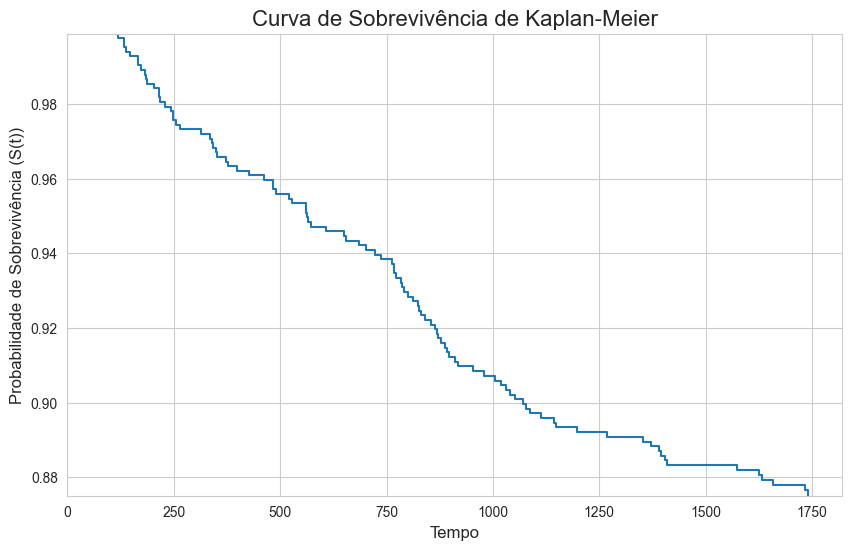

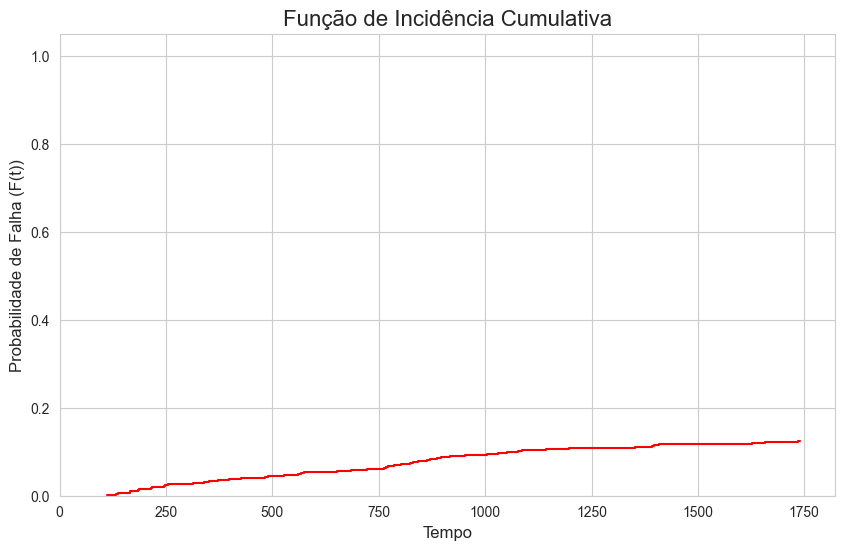

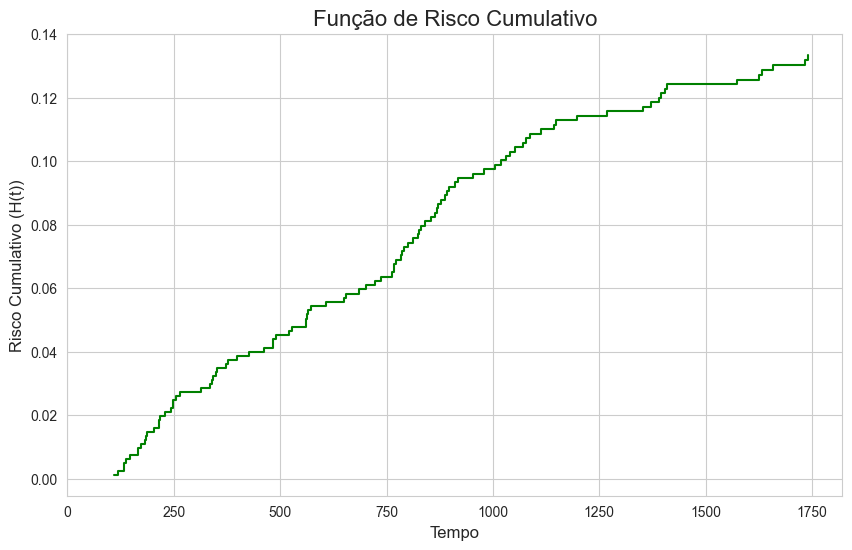

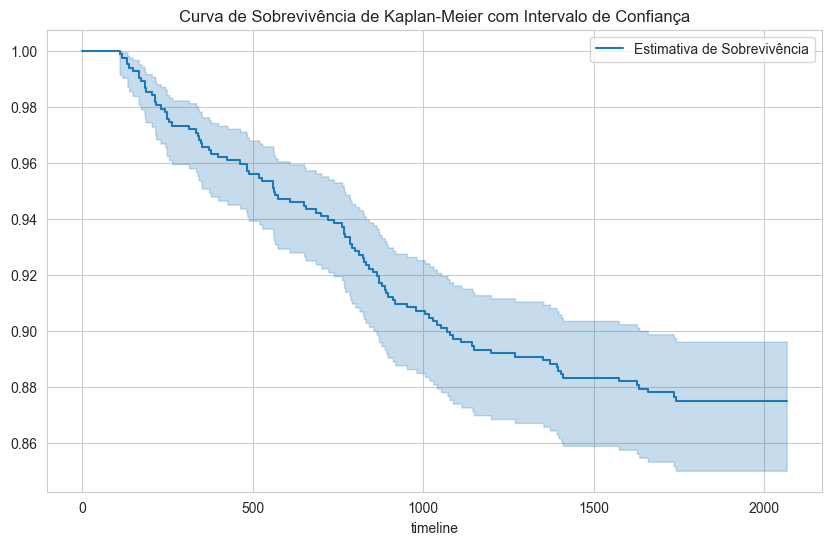

In [17]:
plot_kaplan_meier(resumo_final)

In [18]:
print("\nRESUMO FINAL:")
resumo_final


RESUMO FINAL:


,tempo,S(t),F(t),Erro Padrão,95% CI Lower,95% CI Upper
0,110,0.998789,0.001211,0.001210,0.996418,1.000000
1,118,0.997577,0.002423,0.001711,0.994223,1.000000
2,133,0.995147,0.004853,0.002421,0.990403,0.999891
3,138,0.993932,0.006068,0.002705,0.988629,0.999235
4,148,0.992717,0.007283,0.002962,0.986910,0.998523
...,...,...,...,...,...,...
92,1626,0.880629,0.119371,0.011439,0.858209,0.903050
93,1633,0.879327,0.120673,0.011496,0.856795,0.901859
94,1658,0.877990,0.122010,0.011556,0.855341,0.900640
95,1734,0.876527,0.123473,0.011629,0.853734,0.899320


In [19]:
# --- Verificação manual para TODOS os tempos com eventos ---
print("\nVERIFICAÇÃO MANUAL DETALHADA - TODOS OS TEMPOS:")
print("-" * 80)

for tempo in sorted(dados[dados['evento'] == 1]['tempo'].unique()):
    em_risco = (dados['tempo'] >= tempo).sum()
    eventos = dados[(dados['tempo'] == tempo) & (dados['evento'] == 1)].shape[0]
    prob_sobrev = (em_risco - eventos) / em_risco
    
    print(f"\nTempo {tempo}:")
    print(f"  - Em risco: {em_risco} pessoas")
    print(f"  - Eventos: {eventos} pessoas") 
    print(f"  - Sobreviventes: {em_risco - eventos} pessoas")
    print(f"  - Probabilidade de sobreviver: {em_risco - eventos}/{em_risco} = {prob_sobrev:.3f}")
    
    # Mostrar quais indivíduos estão em risco
    individuos_risco = dados[dados['tempo'] >= tempo]['tempo'].tolist()
    print(f"  - Indivíduos em risco (tempos): {individuos_risco}")
    
    # Mostrar quais tiveram evento neste tempo
    individuos_evento = dados[(dados['tempo'] == tempo) & (dados['evento'] == 1)].index.tolist()
    if individuos_evento:
        print(f"  - Índices que tiveram evento: {individuos_evento}")


print(f"\nINTERPRETAÇÃO:")
print("S(t) = Probabilidade de sobreviver além do tempo t")
print("F(t) = Probabilidade de ter evento até o tempo t")
print("Exemplo: S(122) =", f"{lista_S[list(resumo_final['tempo']).index(122)]:.3f}" if 122 in list(resumo_final['tempo']) else "N/A")


VERIFICAÇÃO MANUAL DETALHADA - TODOS OS TEMPOS:
--------------------------------------------------------------------------------

Tempo 110:
  - Em risco: 826 pessoas
  - Eventos: 1 pessoas
  - Sobreviventes: 825 pessoas
  - Probabilidade de sobreviver: 825/826 = 0.999
  - Indivíduos em risco (tempos): [110, 116, 118, 122, 125, 133, 133, 138, 148, 153, 166, 166, 173, 173, 177, 179, 183, 183, 184, 186, 204, 214, 214, 215, 217, 230, 244, 248, 248, 254, 255, 259, 264, 270, 287, 313, 334, 339, 342, 343, 350, 351, 357, 372, 374, 377, 378, 378, 399, 410, 426, 463, 471, 475, 482, 482, 484, 489, 506, 520, 528, 560, 561, 562, 566, 573, 599, 608, 651, 655, 685, 701, 706, 722, 738, 762, 767, 768, 771, 784, 786, 790, 801, 813, 823, 826, 831, 841, 854, 863, 869, 871, 878, 887, 892, 896, 911, 918, 938, 951, 952, 980, 992, 996, 1005, 1018, 1030, 1040, 1052, 1071, 1077, 1080, 1087, 1112, 1124, 1144, 1149, 1198, 1269, 1352, 1365, 1371, 1387, 1391, 1393, 1393, 1396, 1405, 1405, 1405, 1406, 1409, 1498, 

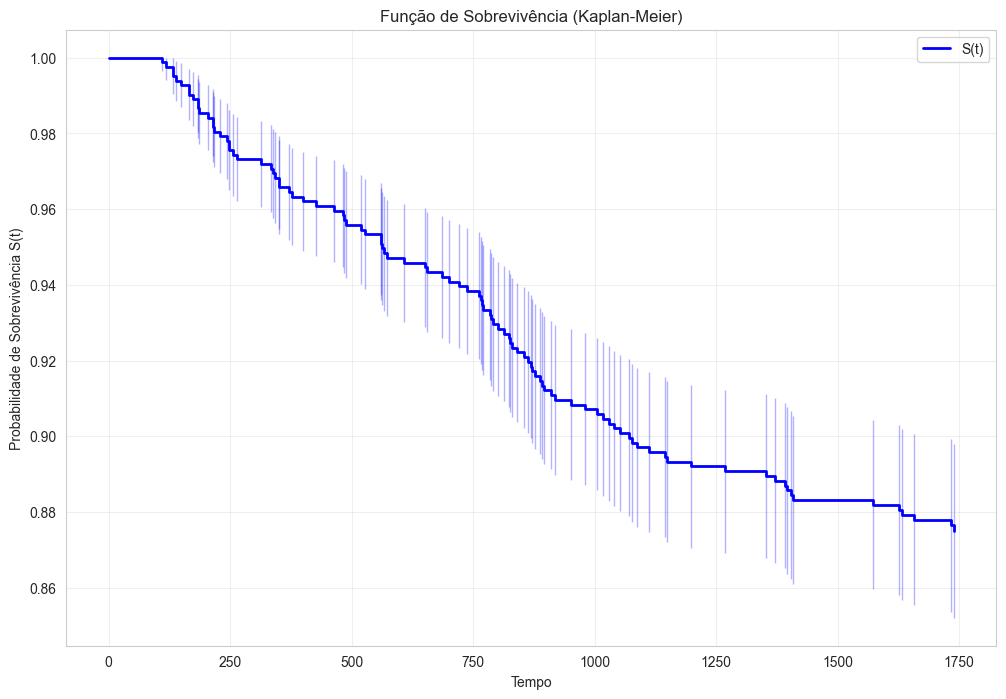

In [20]:
# --- 7. Plot da curva de sobrevivência ---
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Plot principal
tempos_plot = [0] + list(resumo_final['tempo'])
S_plot = [1.0] + list(resumo_final['S(t)'])

plt.step(tempos_plot, S_plot, where='post', linewidth=2, color='blue', label='S(t)')

# Adicionar intervalo de confiança
for i, row in resumo_final.iterrows():
    plt.fill_between([row['tempo'], row['tempo']], 
                     [row['95% CI Lower'], row['95% CI Lower']], 
                     [row['95% CI Upper'], row['95% CI Upper']], 
                     alpha=0.3, color='blue')

plt.xlabel('Tempo')
plt.ylabel('Probabilidade de Sobrevivência S(t)')
plt.title('Função de Sobrevivência (Kaplan-Meier)')
plt.grid(True, alpha=0.3)
#plt.ylim(0, 1.1)
plt.legend()
plt.show()

Usando a Biblioteca para comparar 

          Sobrevivência
timeline               
0.0            1.000000
110.0          0.998789
116.0          0.998789
118.0          0.997577
122.0          0.997577
...                 ...
2042.0         0.875036
2043.0         0.875036
2044.0         0.875036
2045.0         0.875036
2065.0         0.875036

[377 rows x 1 columns]


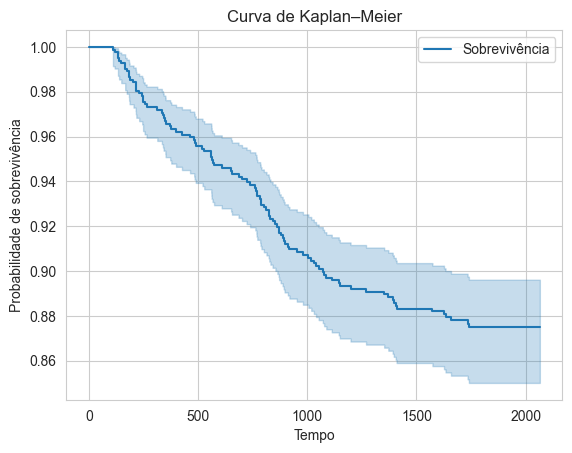

In [21]:
import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# # Dados fictícios
# tempos = [5, 6, 6, 2, 4, 4, 3, 8, 10, 7]
# eventos = [1, 0, 1, 1, 0, 1, 1, 0, 1, 1]  # 1 = evento, 0 = censura

# Criando o estimador Kaplan-Meier
kmf = KaplanMeierFitter()

# Ajusta o modelo aos dados
kmf.fit(durations=dados['tempo'], event_observed=dados['evento'], label="Sobrevivência")

# Mostra as probabilidades estimadas
print(kmf.survival_function_)

# Gráfico
kmf.plot_survival_function()
plt.title("Curva de Kaplan–Meier")
plt.xlabel("Tempo")
plt.ylabel("Probabilidade de sobrevivência")
plt.show()


# Entrando na parte de regressão

## Pressupostos dos modelos de regressão múltipla por mínimos quadrados ordinários (MQO ou OLS)



In [22]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan



# ==============================================================
# --- NOVO BLOCO: Regressão OLS (mínimos quadrados ordinários)
# ==============================================================

# Exemplo: queremos prever "tempo" a partir do "evento"
# (só para fins didáticos, depois você pode trocar por variáveis reais)
X = dados[['evento','genero','idade']]  # variáveis independentes
X = sm.add_constant(X)  # adiciona o intercepto
y = dados['tempo']      # variável dependente

# Ajustar o modelo OLS
modelo = sm.OLS(y, X).fit()

# reseceber os residuos do modelo
residuos = modelo.resid

print("\nResumo da Regressão OLS:")
print(modelo.summary())



Resumo da Regressão OLS:
                            OLS Regression Results                            
Dep. Variable:                  tempo   R-squared:                       0.534
Model:                            OLS   Adj. R-squared:                  0.532
Method:                 Least Squares   F-statistic:                     313.7
Date:                Tue, 09 Sep 2025   Prob (F-statistic):          1.02e-135
Time:                        22:07:59   Log-Likelihood:                -5958.2
No. Observations:                 826   AIC:                         1.192e+04
Df Residuals:                     822   BIC:                         1.194e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1710.6394     

In [23]:
dados

,tempo,evento,idade,genero
0,110,1,74,1
1,116,0,56,1
2,118,1,64,1
3,122,0,52,1
4,125,0,72,1
...,...,...,...,...
821,2043,0,70,1
822,2044,0,56,0
823,2044,0,69,1
824,2045,0,58,1


# Pressupostos dos modelos de regressão múltipla por MQO (OLS)

| **Pressuposto**                                                                 | **Violação**                                                                 | **Verificação do Pressuposto**                                      |
|---------------------------------------------------------------------------------|-------------------------------------------------------------------------------|----------------------------------------------------------------------|
| Os resíduos apresentam distribuição normal.                                     | O valor-p dos testes t e do teste F não são válidos.                         | - Teste de Shapiro-Wilk <br> - Teste de Shapiro-Francia              |
| Não há correlações elevadas entre as variáveis explicativas e há mais observações do que variáveis explicativas. | Multicolinearidade.                                                          | - Matriz de Correlação Simples <br> - Determinantes da matriz (X'X) <br> - VIF (Variance Inflation Factor) e Tolerance |
| Os resíduos não apresentam correlação com qualquer variável X.                   | Heterocedasticidade.                                                          | - Teste de Breusch-Pagan / Cook Weisberg                             |
| Os resíduos são aleatórios e independentes.                                      | Autocorrelação dos resíduos para modelos temporais.                          | - Teste de Durbin-Watson <br> - Teste de Breusch-Godfrey              |


### Pressuposto da normalidade dos resíduos

- Teste de Hipótese dos modelos de regressão. Este pressuposto assegura que o valor-p teste-t e do teste-F sejam válidos.
- A violação deste pressuposto pode ser minimizada com o uso de grandes amostra.

Pressupostoda normalidade dos resíduos 


### Teste de Normalidade

Shapiro–Wilk

- Shapiro–Wilk muito usado em amostras pequenas (< 2000), sensível a desvios.

# 📊 Testes de Normalidade dos Resíduos

| Teste              | Hipótese Nula (H₀)                          | Estatística       | P-Valor       | Interpretação                         |
|--------------------|---------------------------------------------|------------------|--------------|---------------------------------------|
| **Shapiro–Wilk**   | Os resíduos seguem distribuição normal      | W = ...          | p = ...      | p < 0.05 → rejeita normalidade        |
| **Jarque–Bera**    | Os resíduos seguem distribuição normal      | JB = ...         | p = ...      | p < 0.05 → rejeita normalidade        |
|                    | **Extras:** Assimetria = ..., Curtose = ... |                  |              | Normalidade esperada: assimetria ≈ 0 e curtose ≈ 3 |
| **Qui-Quadrado**   | Frequência observada ≈ frequência esperada  | χ² = ...         | p = ...      | p < 0.05 → rejeita normalidade        |

---

### 🔎 Como interpretar:
- **Se p ≥ 0.05** → Não há evidência contra normalidade (aceitamos H₀).  
- **Se p < 0.05** → Evidência de que os resíduos **não** seguem distribuição normal.  

### 📝 Observações:
- **Shapiro–Wilk** é mais usado em amostras pequenas (n < 50).  
- **Jarque–Bera** é baseado em assimetria e curtose (bom para grandes amostras).  
- **Qui-Quadrado** compara frequências em classes, mas depende da escolha de intervalos.  


In [24]:
from scipy import stats
import numpy as np


# --- Definir número de classes (Regra de Sturges) ---
n = len(residuos)

k = int(1 + 3.3 * np.log10(n))  # número de classes
print(f"Número de classes sugerido: {k}")

Número de classes sugerido: 10


In [25]:
# --- Construir tabela de frequências ---
freq, bins = np.histogram(residuos, bins=k)  # frequências absolutas
intervalos = [f"[{round(bins[i],2)} ; {round(bins[i+1],2)})" for i in range(len(bins)-1)]
pt_medio = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)]
frequencia = freq
rel = freq / n

tabela = pd.DataFrame({
    "intervalo": intervalos,
    "pt_medio": pt_medio,
    "frequencia": frequencia,
    "relativa": rel
})

print("\n--- Tabela de Frequência ---")
print(tabela)


--- Tabela de Frequência ---
               intervalo     pt_medio  frequencia  relativa
0  [-1681.99 ; -1411.63) -1546.809029          16  0.019370
1  [-1411.63 ; -1141.27) -1276.449126           8  0.009685
2   [-1141.27 ; -870.91) -1006.089224           1  0.001211
3    [-870.91 ; -600.55)  -735.729321           7  0.008475
4    [-600.55 ; -330.19)  -465.369418          37  0.044794
5     [-330.19 ; -59.83)  -195.009515         116  0.140436
6      [-59.83 ; 210.53)    75.350388         560  0.677966
7      [210.53 ; 480.89)   345.710291          68  0.082324
8      [480.89 ; 751.25)   616.070194           7  0.008475
9     [751.25 ; 1021.61)   886.430096           6  0.007264


In [26]:
# --- Estatísticas descritivas ---
media = np.mean(residuos)
desvio_padrao = np.std(residuos, ddof=1)

print("\n--- Estatísticas ---")
print(f"Média: {media}")
print(f"Desvio padrão: {desvio_padrao:.3f}")


--- Estatísticas ---
Média: -6.2101091016940865e-12
Desvio padrão: 328.629


In [27]:
# --- Teste de normalidade Shapiro-Wilk ---
statistic, pvalue = stats.shapiro(residuos)
print(f"Shapiro-Wilk: Estatistica {statistic}, P-value: {pvalue}")

Shapiro-Wilk: Estatistica 0.6852049763649983, P-value: 1.5052920700083477e-36


In [28]:
if pvalue > 0.05:
    print("Não rejeitamos H0 → resíduos parecem normais")
else:
    print("Rejeitamos H0 → resíduos não são normais")

Rejeitamos H0 → resíduos não são normais


Teste Jarque-Bera

O teste de Jarque-Bera avalia a normalidade com base na assimetria e na curtose dos dados.\
Ele calcula a diferença entre a assimetria e a curtose observadas e o que seria esperado em uma distribuição normal.\
Se a diferença for muito grande, os dados não são normalmente distribuídos.

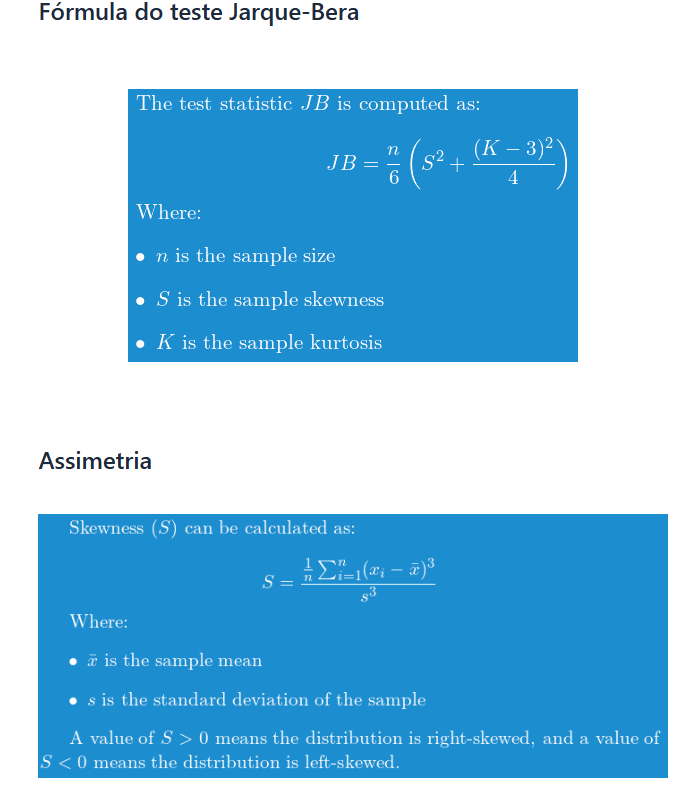

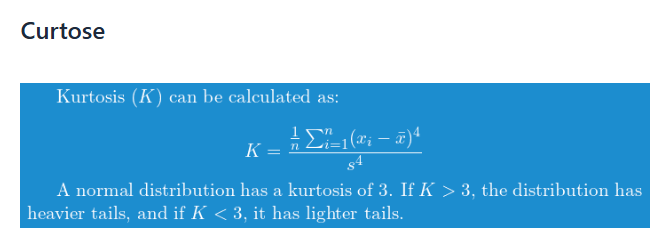

link de estudo 
https://dataaspirant.com/jarque-bera-test/

In [29]:
import statsmodels.stats.api as sms
# --- Normalidade (Jarque-Bera)
jb_test, p_value, assimetria, curtose   = sms.jarque_bera(residuos)

# A estatística de teste de Jarque-Bera testa a hipótese nula de que os dados 
# são normalmente distribuídos em relação a uma alternativa de que os dados seguem 
# alguma outra distribuição. A estatística de teste baseia-se em dois momentos dos 
# dados, a assimetria e a curtose, e tem uma distribuição assintótica.

print("Jarque-Bera:", jb_test)
print("P-Value:", p_value)
print("Assimetria:", assimetria)
print("Curtose:", curtose)



Jarque-Bera: 5233.488928078369
P-Value: 0.0
Assimetria: -2.7228955771196355
Curtose: 14.063724101641512


Jarque-Bera: 5411.902772711335 - JB alto indica forte desvio.\
P-Value: 0.0 - p ≪ 0.05 → rejeita normalidade.\
Assimetria: -2.765968950098913 - Assimetria positiva → cauda longa à direita.\
Curtose: 14.253631979743798 - Curtose > 3 → caudas pesadas.

#### Interpretação prática:

#### 1. Valor de jb_test:
- Quanto maior for, maior o desvio da normalidade.
- Mas o que realmente importa é o p-value associado.

#### 2. P-Value (p_value):
- Se p < 0.05 → rejeitamos H₀ → os resíduos não são normais.
- Se p ≥ 0.05 → não rejeitamos H₀ → não temos evidência contra a normalidade.

#### 3. Assimetria (assimetria):
- Medida de simetria da distribuição.
- Valor esperado para normal = 0.
- Valores positivos → cauda à direita (longa).
- Valores negativos → cauda à esquerda.

#### 4. Curtose (curtose):
- Medida de “achatamento” da curva.
- Valor esperado para normal = 3.
- 3 → distribuição mais pontuda (caudas pesadas).
- < 3 → distribuição mais achatada (caudas leves).

In [30]:
# --- Teste Qui-quadrado de aderência à normalidade ---
# Para isso: usar as frequências observadas vs. esperadas de uma Normal
obs_freq = freq
esperadas = []
for i in range(len(bins)-1):
    # probabilidade do intervalo sob a normal teórica
    p_i = stats.norm.cdf(bins[i+1], loc=media, scale=desvio_padrao) - \
          stats.norm.cdf(bins[i], loc=media, scale=desvio_padrao)
    esperadas.append(p_i * n)


##  Normaliza para que soma esperadas = soma observadas
esperadas = np.array(esperadas)
esperadas = esperadas * (obs_freq.sum() / esperadas.sum())

chi2_stat, chi2_p = stats.chisquare(obs_freq, f_exp=esperadas)

print("\n--- Teste Qui-Quadrado ---")
print(f"Qui²: {chi2_stat:.3f}, P-valor: {chi2_p:.4f}")



--- Teste Qui-Quadrado ---
Qui²: 36985.496, P-valor: 0.0000


In [31]:
if chi2_p > 0.05:
    print("Não rejeitamos H0 → resíduos parecem normais")
else:
    print("Rejeitamos H0 → resíduos não são normais")

Rejeitamos H0 → resíduos não são normais


In [32]:
from sfrancia import shapiroFrancia

# Realizar o teste de Shapiro-Francia
resultado = shapiroFrancia(residuos)

print(f'Método: {resultado['method']}')
print(f"Estatística do teste (W'): {resultado['statistics W']}")
print(f"Estatística Z: {resultado['statistics z']}")
print(f"P-valor: {resultado['p-value']}")
# Interpretação do resultado

alpha = 0.05
if resultado['p-value'] > alpha:
    print("Conclusão: Não há evidências para rejeitar a hipótese nula. Os dados parecem ser normalmente distribuídos.")
else:
    print("Conclusão: Rejeita-se a hipótese nula. Os dados não parecem ser normalmente distribuídos.")

print("\n" + "="*40 + "\n")

Método: Shapiro-Francia normality test
Estatística do teste (W'): 0.6837255882101925
Estatística Z: 11.742094488513736
P-valor: 3.8770979775060394e-32
Conclusão: Rejeita-se a hipótese nula. Os dados não parecem ser normalmente distribuídos.




vizualização

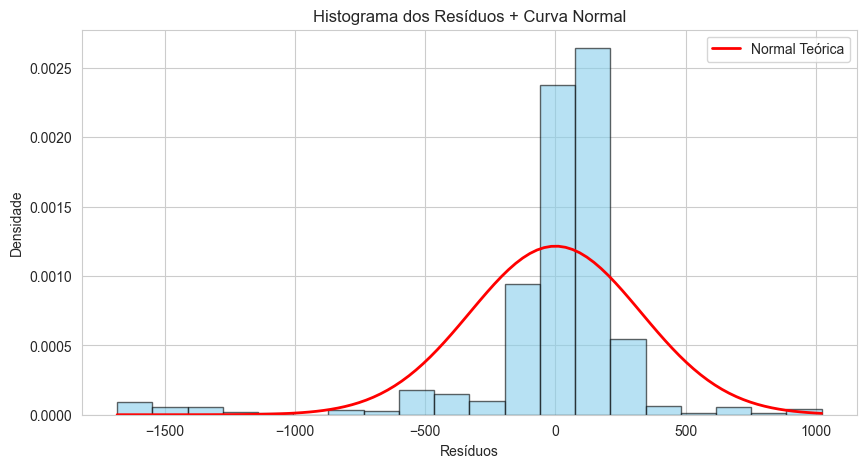

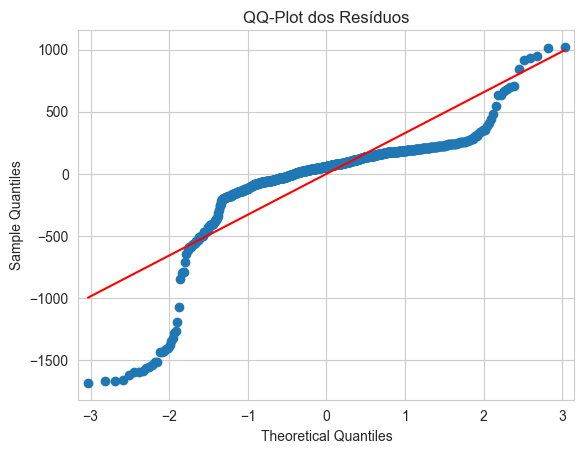

In [33]:
import numpy as np
import matplotlib.pyplot as plt
# import scipy.stats as stats
# import statsmodels.api as sm

# --- Histograma + Curva Normal Teórica ---
plt.figure(figsize=(10,5))
count, bins, ignored = plt.hist(residuos, bins=20, density=True, alpha=0.6, color='skyblue', edgecolor="black")

# curva normal ajustada com mesma média e desvio
media, desvio = np.mean(residuos), np.std(residuos)
x = np.linspace(min(residuos), max(residuos), 100)
plt.plot(x, stats.norm.pdf(x, media, desvio), 'r-', lw=2, label="Normal Teórica")

plt.title("Histograma dos Resíduos + Curva Normal")
plt.xlabel("Resíduos")
plt.ylabel("Densidade")
plt.legend()
plt.show()

# --- QQ-plot ---
sm.qqplot(residuos, line='s')
plt.title("QQ-Plot dos Resíduos")
plt.show()


# Pressuposto da Multicolinearidade

- Mariz de Correlação Simples.
- Determinantes da matriz (X´X)
- VIF (Variance inflation Factor) e Tolerance.

# Correlação


| 🧠 **Correlação** | ✅ **Ideal para...**                            | 🔢 **Pode usar com dados discretos?** |
|------------------|-------------------------------------------------|---------------------------------------|
| **Pearson**      | Relação linear entre variáveis contínuas        | Sim, desde que haja variabilidade     |
| **Spearman**     | Dados discretos, ordinais, relações não-lineares| Sim, **recomendado**                  |
| **Kendall Tau**  | Pequenos conjuntos com muitos empates           | Sim, **boa escolha**                  |

In [34]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 826 entries, 0 to 825
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   tempo   826 non-null    int64
 1   evento  826 non-null    int64
 2   idade   826 non-null    int64
 3   genero  826 non-null    int64
dtypes: int64(4)
memory usage: 32.3 KB


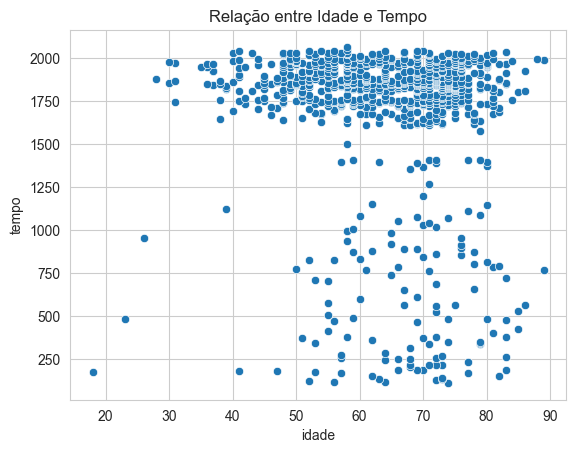

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# tempo (Alvo): Contínua (int64)
# idade: Contínua (int64)
# evento: Categórica/Binária (ex: 0 = não ocorreu, 1 = ocorreu)
# genero: Categórica/Binária (ex: 0 = masculino, 1 = feminino)


# 1. Visualizar a relação com um gráfico de dispersão
sns.scatterplot(data=dados, x='idade', y='tempo')
plt.title('Relação entre Idade e Tempo')
plt.show()

Coeficiente de Correlação de Pearson 

In [36]:

# Coeficiente de Pearson
pearson_corr = dados['tempo'].corr(dados['idade'], method='pearson')
print(f"Correlação de Pearson entre tempo e idade: {pearson_corr:.4f}")

Correlação de Pearson entre tempo e idade: -0.1148


Coeficiente de Correlação de Spearman 

In [37]:
spearman_corr = dados['tempo'].corr(dados['idade'], method='spearman')
print(f"Correlação de Spearman entre tempo e idade: {spearman_corr:.4f}")

Correlação de Spearman entre tempo e idade: -0.1191


Correlação entre tempo e genero/evento

In [38]:
# Para a variável 'genero'
ponto_bisserial_genero = dados['tempo'].corr(dados['genero'], method='pearson')
print(f"Correlação Ponto-Bisserial (gênero): {ponto_bisserial_genero:.4f}")

# Para a variável 'evento'
ponto_bisserial_evento = dados['tempo'].corr(dados['evento'], method='pearson')
print(f"Correlação Ponto-Bisserial (evento): {ponto_bisserial_evento:.4f}")

Correlação Ponto-Bisserial (gênero): -0.0355
Correlação Ponto-Bisserial (evento): -0.7298


 Análise Gráfica com Boxplots

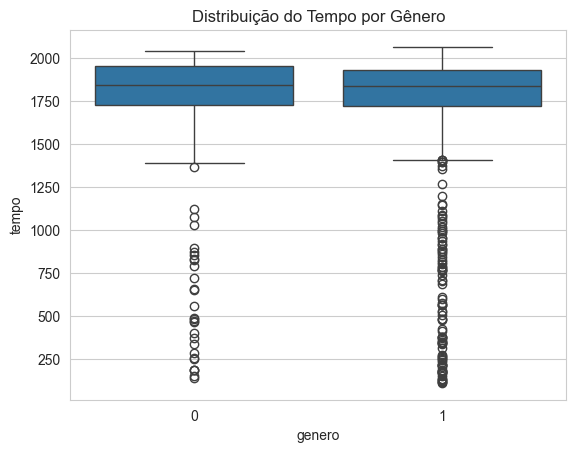

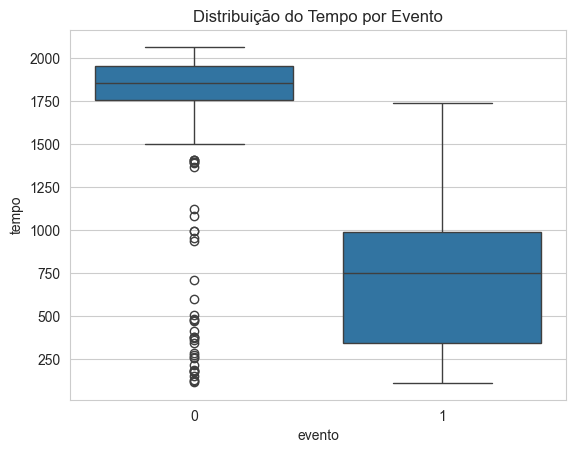

In [39]:
# Comparando 'tempo' por 'genero'
sns.boxplot(data=dados, x='genero', y='tempo')
plt.title('Distribuição do Tempo por Gênero')
plt.show()

# Comparando 'tempo' por 'evento'
sns.boxplot(data=dados, x='evento', y='tempo')
plt.title('Distribuição do Tempo por Evento')
plt.show()

Teste T de Student

In [40]:
from scipy import stats

# Separa os dados em dois grupos com base no gênero
grupo_0 = dados[dados['genero'] == 0]['tempo']
grupo_1 = dados[dados['genero'] == 1]['tempo']

# Realiza o Teste T
t_stat, p_valor = stats.ttest_ind(grupo_0, grupo_1)
print(f"Teste T para gênero: Estatística= {t_stat:.4f}, P-valor= {p_valor:.4f}")


if p_valor < 0.05:
    print("A diferença nas médias de tempo entre os gêneros é significativa.")
else:
    print("A diferença nas médias de tempo entre os gêneros não é significativa.")

Teste T para gênero: Estatística= 1.0205, P-valor= 0.3078
A diferença nas médias de tempo entre os gêneros não é significativa.


In [41]:
dados

,tempo,evento,idade,genero
0,110,1,74,1
1,116,0,56,1
2,118,1,64,1
3,122,0,52,1
4,125,0,72,1
...,...,...,...,...
821,2043,0,70,1
822,2044,0,56,0
823,2044,0,69,1
824,2045,0,58,1


In [42]:

# Separa os dados em dois grupos com base na idade
grupo_0 = dados[dados['evento'] == 0]['tempo']
grupo_1 = dados[dados['evento'] == 1]['tempo']

# Realiza o Teste T
t_stat, p_valor = stats.ttest_ind(grupo_0, grupo_1)
print(f"Teste T para evento: Estatística= {t_stat:.4f}, P-valor= {p_valor:.4f}")


if p_valor < 0.05:
    print("A diferença nas médias de tempo entre os evento é significativa.")
else:
    print("A diferença nas médias de tempo entre os evento não é significativa.")

Teste T para evento: Estatística= 30.6421, P-valor= 0.0000
A diferença nas médias de tempo entre os evento é significativa.


In [43]:
dados[['genero', 'tempo']].corr(method='kendall')

,genero,tempo
genero,1.000000,-0.020133
tempo,-0.020133,1.000000


In [44]:
# Calcular a matriz de correlação de Pearson
matriz_corr = dados.corr(method='pearson')

# Exibir a matriz 
print("Matriz de Correlação:")
print(matriz_corr)

Matriz de Correlação:
           tempo    evento     idade    genero
tempo   1.000000 -0.729794 -0.114806 -0.035528
evento -0.729794  1.000000  0.203122  0.035658
idade  -0.114806  0.203122  1.000000 -0.112449
genero -0.035528  0.035658 -0.112449  1.000000


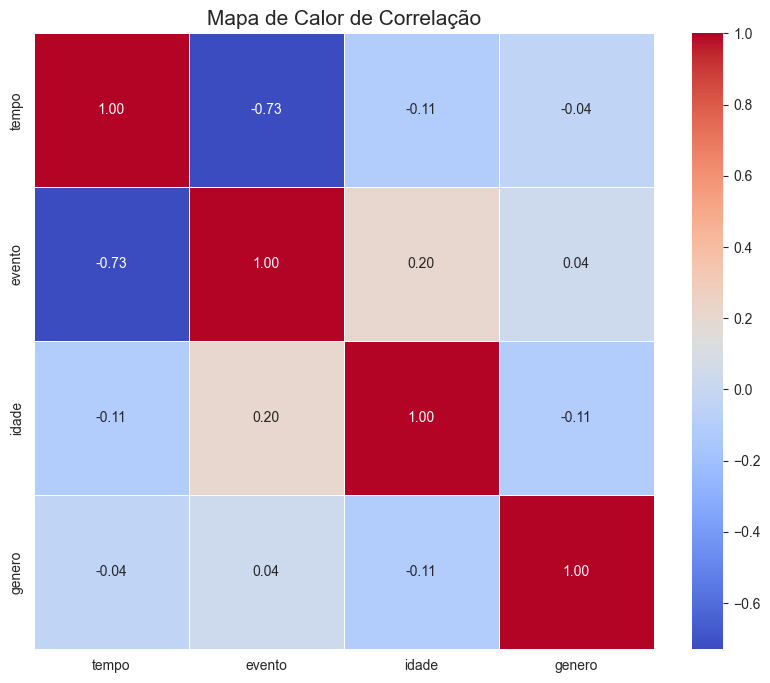

In [45]:
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, 
            annot=True,        # Mostra os valores nas células
            fmt=".2f",         # Formata os números com 2 casas decimais
            cmap='coolwarm',   # Define o mapa de cores
            linewidths=.5)     # Adiciona linhas entre as células

plt.title('Mapa de Calor de Correlação', fontsize=15)
plt.show()

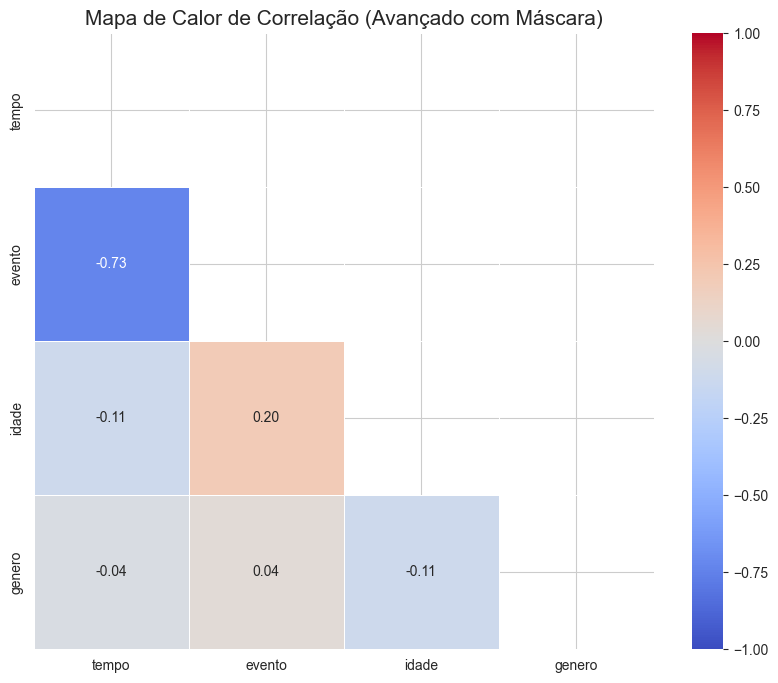

In [46]:
# Criar uma máscara para a parte triangular superior
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(matriz_corr, 
            mask=mask,         # Aplica a máscara
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm',
            linewidths=.5,
            vmin=-1, vmax=1)   # Garante que a barra de cores vá de -1 a 1

plt.title('Mapa de Calor de Correlação (Avançado com Máscara)', fontsize=15)
plt.show()

### VIF (Variance Inflation Factor)

O **VIF (Fator de Inflação de Variância)** mede o quanto a variância do coeficiente de uma variável é "inflada" pela presença de outras variáveis correlacionadas no modelo.

* **O que significa?** * Ele quantifica o quão mais instável (maior variância) é a estimativa de um coeficiente por causa da multicolinearidade.

* **Interpretação:**
    * `VIF = 1`: Não há correlação alguma entre a variável e as outras. Este é o cenário ideal.
    * `1 < VIF < 5`: Correlação moderada, geralmente considerada aceitável.
    * `VIF > 5 ou 10`: Correlação alta e preocupante. Um VIF de 10 significa que a variância do coeficiente dessa variável é 10 vezes maior do que seria se não houvesse multicolinearidade. Isso indica que o coeficiente é instável e pouco confiável.

---

### Tolerance

A **Tolerance (Tolerância)** é simplesmente o inverso do VIF.

$$
\text{Tolerance} = \frac{1}{\text{VIF}}
$$

* **O que significa?**
    * Ela representa a porcentagem da variância em uma variável que **não é explicada** pelas outras variáveis independentes.

* **Interpretação:**
    * É o oposto do VIF.
    * `Tolerance = 1`: Nenhuma correlação.
    * `Tolerance < 0.2 ou 0.1`: Correlação alta e preocupante (corresponde a um VIF > 5 ou 10). Valores baixos indicam que a maior parte da variância da variável já está sendo explicada pelas outras, tornando-a redundante.

Fonte: https://en.wikipedia.org/wiki/Variance_inflation_factor#:~:text=The%20VIF%20provides%20an%20index,is%20increased%20because%20of%20collinearity.

In [47]:

# # ---  Multicolinearidade (VIF) ---
# print("\nVIF (Variance Inflation Factor):")
# vif = pd.DataFrame()
# vif["variável"] = X.columns
# vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
# print(vif)

# # ---  Heterocedasticidade (Breusch–Pagan) ---
# bp_test = het_breuschpagan(modelo.resid, X)
# labels = ['LM Stat', 'p-value', 'F-Stat', 'F p-value']
# print("\nTeste de Breusch–Pagan para heterocedasticidade:")
# print(dict(zip(labels, bp_test)))

In [48]:
y

0       110
1       116
2       118
3       122
4       125
       ... 
821    2043
822    2044
823    2044
824    2045
825    2065
Name: tempo, Length: 826, dtype: int64

In [49]:
#Calcula o VIF para cada variável
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

In [50]:
vif_data

for x,y in zip(vif_data['feature'], vif_data['VIF']):
    if x == 'const':  # Pula a iteração se a feature for a constante
        continue
    
    if (1 < y)  and (y < 5):
        print(f'Variável: {x}, valor: {y} <-- Correlação moderada, geralmente considerada aceitável.')
    elif y > 5:
            print(f'Variável: {x}, valor: {y} <-- Correlação alta e preocupante. Pode indicar multicolinearidade severa.')
    else:
            print(f'Variável: {x}, valor: {y} <-- Correlação baixa, ideal para modelos preditivos.')

Variável: evento, valor: 1.0468182470719836 <-- Correlação moderada, geralmente considerada aceitável.
Variável: genero, valor: 1.0164814120717582 <-- Correlação moderada, geralmente considerada aceitável.
Variável: idade, valor: 1.0588764511283788 <-- Correlação moderada, geralmente considerada aceitável.


### Diagnósticos de coliearidade de Belsley-Kun-Welsahn (BKW)

In [51]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

def bkw_com_lambda(X, scale=True, return_vif=True, tiny_tol=1e-12):
    """
    Belsley-Kuh-Welsch (BKW) com saída usando autovalores (lambda) ordenados do maior para o menor.

    Parâmetros:
    -----------
    X : pd.DataFrame ou np.ndarray
        Matriz de preditores (pode já conter constante).
    scale : bool
        Se True, padroniza (centra e divide pelo desvio padrão) antes do cálculo.
    return_vif : bool
        Se True e X for DataFrame, calcula VIF.
    tiny_tol : float
        Limiar para considerar um autovalor ≈ 0 e evitar divisão por zero.

    Retorno:
    --------
    dict com:
      - lambda_vals: pd.Series (autovalores ordenados desc)
      - condition_index: pd.Series (CI por componente)
      - variance_decomposition: DataFrame (linhas = variáveis, colunas = Comp_1...Comp_p)
      - bkw_table: DataFrame (mesma vdp com linha extra "Condition Index" e "lambda")
      - vif: DataFrame (opcional)
    """
    # converter e obter nomes
    if isinstance(X, pd.DataFrame):
        cols = X.columns.tolist()
        Xmat = X.values.astype(float)
    else:
        Xmat = np.asarray(X, dtype=float)
        cols = [f"x{i}" for i in range(Xmat.shape[1])]

    # padroniza (recomendado)
    if scale:
        mu = Xmat.mean(axis=0)
        sigma = Xmat.std(axis=0, ddof=1)
        sigma[sigma == 0] = 1.0
        Xs = (Xmat - mu) / sigma
    else:
        Xs = Xmat.copy()

    # matriz X'X
    XtX = Xs.T.dot(Xs)

    # autovalores e autovetores (eigh é estável para simétrica) -> retorna ascendente
    eigvals, eigvecs = np.linalg.eigh(XtX)  # eigvals ascending

    # ordenar do maior para o menor
    idx_desc = np.argsort(eigvals)[::-1]
    lambda_sorted = eigvals[idx_desc]
    V = eigvecs[:, idx_desc]  # colunas são autovetores correspondentes

    # tratar autovalores muito pequenos
    lambda_proc = lambda_sorted.copy()
    lambda_proc[lambda_proc < tiny_tol] = np.nan  # marca pequenos como NaN para evitar divisão

    # condition index: sqrt(lambda_max / lambda_k)
    lambda_max = lambda_sorted[0]
    cond_idx = np.sqrt(lambda_max / lambda_sorted)
    cond_idx[np.isinf(cond_idx)] = np.inf
    cond_idx[np.isnan(lambda_sorted)] = np.inf

    # calcular phi = (v_jk^2) / lambda_k  (v_jk: entrada j da coluna k de V)
    # V shape: (p, p), lambda_proc shape: (p,)
    phi = (V**2) / lambda_proc[np.newaxis, :]    # - terá NaN onde lambda_proc é NaN

    # normaliza por linha para obter proporções de decomposição de variância
    row_sums = np.nansum(phi, axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    vdp = phi / row_sums

    comp_names = [f"Comp_{k+1}" for k in range(V.shape[1])]
    vdp_df = pd.DataFrame(vdp, index=cols, columns=comp_names)

    # montar tabela BKW: incluir lambda (autovalores) e Condition Index como última linha
    lambda_ser = pd.Series(lambda_sorted, index=comp_names)
    cond_ser = pd.Series(cond_idx, index=comp_names)

    bkw_table = vdp_df.copy()
    # adiciona linhas no final (usar .loc para manter ordem)
    bkw_table.loc["lambda"] = lambda_ser
    bkw_table.loc["Condition Index"] = cond_ser

    result = {
        "lambda_vals": lambda_ser,
        "condition_index": cond_ser,
        "variance_decomposition": vdp_df,
        "bkw_table": bkw_table
    }

    if return_vif and isinstance(X, pd.DataFrame):
        # VIF com statsmodels exige matriz sem colunas perfeitamente colineares; pode falhar se houver redundância exata
        try:
            vif_vals = []
            for i in range(X.shape[1]):
                vif_vals.append(variance_inflation_factor(X.values, i))
            result["vif"] = pd.DataFrame({"VIF": vif_vals}, index=cols)
        except Exception as e:
            result["vif_error"] = str(e)

    return result


In [52]:
import statsmodels.api as sm

X = dados[['evento','genero','idade']]
X = sm.add_constant(X)  
y = dados['tempo']

out = bkw_com_lambda(X, scale=True, return_vif=True)
print("Autovalores (lambda) do maior para o menor:\n", out["lambda_vals"])
print("\nCondition Indices:\n", out["condition_index"])
print("\nTabela BKW (proporções) — primeira linhas:\n", out["variance_decomposition"].head())
print("\nTabela BKW completa (com lambda e Condition Index no final):\n", out["bkw_table"])
if "vif" in out:
    print("\nVIFs:\n", out["vif"])
elif "vif_error" in out:
    print("\nErro ao calcular VIF:", out["vif_error"])


Autovalores (lambda) do maior para o menor:
 Comp_1    1005.216104
Comp_2     849.760825
Comp_3     620.023071
Comp_4       0.000000
dtype: float64

Condition Indices:
 Comp_1    1.000000
Comp_2    1.087630
Comp_3    1.273286
Comp_4         inf
dtype: float64

Tabela BKW (proporções) — primeira linhas:
           Comp_1    Comp_2    Comp_3  Comp_4
const   0.000000  0.000000  0.000000     NaN
evento  0.312550  0.207573  0.479877     NaN
genero  0.059280  0.734603  0.206117     NaN
idade   0.409188  0.006478  0.584334     NaN

Tabela BKW completa (com lambda e Condition Index no final):
                       Comp_1      Comp_2      Comp_3  Comp_4
const               0.000000    0.000000    0.000000     NaN
evento              0.312550    0.207573    0.479877     NaN
genero              0.059280    0.734603    0.206117     NaN
idade               0.409188    0.006478    0.584334     NaN
lambda           1005.216104  849.760825  620.023071     0.0
Condition Index     1.000000    1.087630 

In [53]:
import pandas as pd
import pygwalker as pyg



# Forçar PyGWalker a renderizar em HTML
pyg_html = pyg.walk(dados, return_html=True)
from IPython.display import HTML
HTML(pyg_html)


Box(children=(HTML(value='\n<div id="ifr-pyg-00063e680da142f6I9li83CeRcZd6QAb" style="height: auto">\n    <hea…

TypeError: 'PygWalker' object is not subscriptable

In [ ]:
#pyg.walk(dados)

#pyg.walk(dados, spec="./meu_dashboard.json")



In [ ]:
# from pygwalker.api.streamlit import get_streamlit_html
# import streamlit as st

# # Renderiza o PyGWalker dentro do Streamlit
# st.title("Exploração de Dados com PyGWalker")
# st.components.v1.html(
#     get_streamlit_html(dados),
#     height=800,
#     scrolling=True
# )